## **Modeling & Evaluation**

### Project Objective

The objective of this phase is to develop a machine learning model capable of accurately predicting customer churn in an ecommerce platform.

Since the target variable (Churn) contains two classes (0 = Active Customer, 1 = Churned Customer), this project is treated as a Binary Classification problem

The following models will be implemented:

* Logistic Regression
* Decision Tree Classifier

The performance of both models will be evaluated using Accuracy, Precision, Recall, F1 Score, Classification Report, and Confusion Matrix.

In [163]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix,classification_report

### **Load the Dataset**

In [164]:
df = pd.read_csv(r"C:\Users\user\Desktop\Machien learning Project\Data\ecommerce_customer_churn_Feature Engineering.csv")

In [165]:
df.head()

,Age,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,Total_Purchases,...,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter,Gender_Male,Gender_Other,customer_engagement_score,support_intensity_index,purchase_value_index
0,43,2,21,2,14,27.4,6.0,50.6,3,9,...,1.0,953,2278,0,0,1,0,47.4,0.900000,852.48
1,36,6,20,1,15,42.7,10.3,37.7,1,19,...,3.0,1067,3028,0,3,1,0,68.0,0.350000,1566.55
2,45,1,38,2,10,24.8,1.6,70.9,1,9,...,2.0,1289,2317,0,3,0,0,36.4,0.400000,1489.68
3,56,7,27,2,10,38.4,14.8,41.7,9,15,...,3.0,2340,2674,0,0,0,0,63.2,0.125000,2209.95
4,35,4,9,3,29,51.4,8.4,19.1,9,32,...,4.0,3041,5354,0,3,1,0,88.8,0.030303,4521.60


In [166]:
print(df.shape)

(48410, 29)


In [167]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48410 entries, 0 to 48409
Data columns (total 29 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            48410 non-null  int64  
 1   Country                        48410 non-null  int64  
 2   City                           48410 non-null  int64  
 3   Membership_Years               48410 non-null  int64  
 4   Login_Frequency                48410 non-null  int64  
 5   Session_Duration_Avg           48410 non-null  float64
 6   Pages_Per_Session              48410 non-null  float64
 7   Cart_Abandonment_Rate          48410 non-null  float64
 8   Wishlist_Items                 48410 non-null  int64  
 9   Total_Purchases                48410 non-null  int64  
 10  Average_Order_Value            48410 non-null  float64
 11  Days_Since_Last_Purchase       48410 non-null  float64
 12  Discount_Usage_Rate            48410 non-null 

### **Data Leakage Prevention**


Data leakage occurs when information unavailable during prediction is used while training the model. This causes unrealistically high model performance.
To prevent leakage, remove columns such as customer identifiers or columns that directly reveal churn.

In [168]:
df.drop(columns=['CustomerID'], inplace=True, errors='ignore')

df.drop(columns=['Churn Reason','ExitDate'], inplace=True, errors='ignore')

### **Features and Target Variable**

Separate the independent variables (X) from the target variable (y).

In [169]:
X = df.drop('Churned', axis=1)
y = df['Churned']

### **Handle Infinity and Missing Values**

Machine Learning models cannot work with Infinity or Missing Values.
Replace Infinity values with NaN.

In [170]:
X = X.replace([np.inf,-np.inf],np.nan)
X = X.fillna(X.median(numeric_only=True))

### **Check missing value**

In [171]:
X.isnull().sum()

Age                              0
Country                          0
City                             0
Membership_Years                 0
Login_Frequency                  0
Session_Duration_Avg             0
Pages_Per_Session                0
Cart_Abandonment_Rate            0
Wishlist_Items                   0
Total_Purchases                  0
Average_Order_Value              0
Days_Since_Last_Purchase         0
Discount_Usage_Rate              0
Returns_Rate                     0
Email_Open_Rate                  0
Customer_Service_Calls           0
Product_Reviews_Written          0
Social_Media_Engagement_Score    0
Mobile_App_Usage                 0
Payment_Method_Diversity         0
Lifetime_Value                   0
Credit_Balance                   0
Signup_Quarter                   0
Gender_Male                      0
Gender_Other                     0
customer_engagement_score        0
support_intensity_index          0
purchase_value_index             0
dtype: int64

### **Split the Dataset**

Split the dataset into Training data and Testing data.

 80% → Training
 
20% → Testing

In [172]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

### **Feature Scaling**

In [173]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### **Train Logistic Regression Model**

In [174]:
lr_model = LogisticRegression(
    max_iter=5000,
    random_state=42
)

lr_model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,5000
,multi_class,'deprecated'


### **Make Predictions**

In [175]:
lr_pred = lr_model.predict(X_test_scaled)

### **Model Evaluation**

In [176]:
lr_accuracy=accuracy_score(y_test,lr_pred)
lr_precision=precision_score(y_test,lr_pred)
lr_recall=recall_score(y_test,lr_pred)
lr_f1_score=f1_score(y_test,lr_pred)

print("Accuracy :",lr_accuracy)
print("Precision:",lr_precision)
print("Recall :",lr_recall)
print("F1 Score :",lr_f1_score)

Accuracy : 0.783412518074778
Precision: 0.6983050847457627
Recall : 0.4415862808145766
F1 Score : 0.541037426132633


### **Classification Report**

In [177]:
print(classification_report(y_test,lr_pred))

              precision    recall  f1-score   support

           0       0.80      0.92      0.86      6883
           1       0.70      0.44      0.54      2799

    accuracy                           0.78      9682
   macro avg       0.75      0.68      0.70      9682
weighted avg       0.77      0.78      0.77      9682



### **Confusion Matrix**

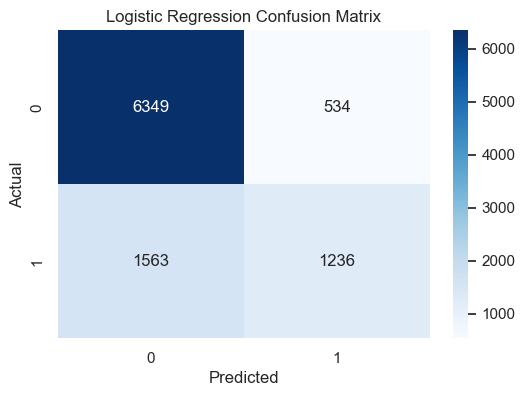

In [178]:
cm=confusion_matrix(y_test,lr_pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Logistic Regression Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

## **Logistic Regression Analysis**

The confusion matrix illustrates the classification performance of the Logistic Regression model by comparing actual customer churn values with predicted values.

### True Negative (TN)

The model correctly predicted customers who did not churn.

### False Positive (FP)

The model incorrectly predicted churn for customers who actually stayed.

### False Negative (FN)

The model failed to identify customers who actually churned.

### True Positive (TP)

The model correctly predicted customers who churned.


### **Findings**


* The model correctly classifies most non-churn customers.
* False positives are relatively low.
* Some churn customers are missed due to false negatives.
* The model provides a good baseline for churn prediction.

### **Conclusion**

Logistic Regression provides good overall classification performance and serves as a simple and interpretable baseline model.

## **Decision Tree Classifier**


Decision Tree learns decision rules from data and captures non-linear relationships.

In [179]:
dt_model=DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

### **Train**

In [180]:
dt_model.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


### **Prediction**

In [182]:
dt_pred=dt_model.predict(X_test)

### **Evaluate Decision Tree**

In [183]:
dt_accuracy=accuracy_score(y_test,dt_pred)
dt_precision=precision_score(y_test,dt_pred)
dt_recall=recall_score(y_test,dt_pred)
dt_f1_score=f1_score(y_test,dt_pred)

print("Accuracy :",dt_accuracy)
print("Precision:",dt_precision)
print("Recall :",dt_recall)
print("F1 Score :",dt_f1_score)

Accuracy : 0.8646973765750878
Precision: 0.8581048581048581
Recall : 0.6373704894605217
F1 Score : 0.7314473144731447


### **Classification Report**

In [184]:
print(classification_report(y_test,dt_pred))45

              precision    recall  f1-score   support

           0       0.87      0.96      0.91      6883
           1       0.86      0.64      0.73      2799

    accuracy                           0.86      9682
   macro avg       0.86      0.80      0.82      9682
weighted avg       0.86      0.86      0.86      9682



### **Confusion Matrix**

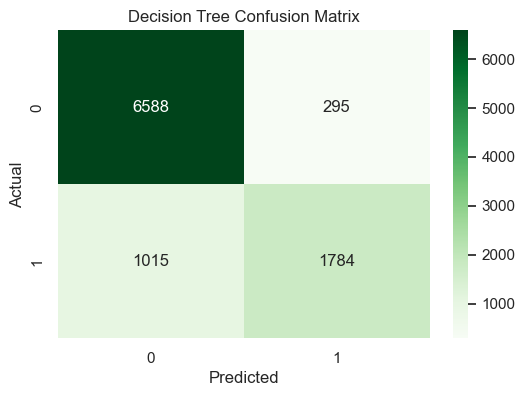

In [185]:
cm=confusion_matrix(y_test,dt_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Greens')
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## **Decision Tree Analysis**

### True Negative (TN)

Correctly predicted customers who did not churn.

### False Positive (FP)

Incorrectly predicted churn for customers who stayed.

### False Negative (FN)

Failed to identify customers who churned.

### True Positive (TP)
Correctly predicted customers who churned.

### **Findings**


* High number of correctly classified customers.
* Better detection of churn customers compared to Logistic Regression.
* Lower false negatives improve recall.
* Suitable for identifying customers likely to churn.


### **Conclusion**

Decision Tree provides better recall and overall classification performance while maintaining competitive accuracy

### **Model Comparison**

In [187]:
comparison=pd.DataFrame({
'Model':['Logistic Regression',
         'Decision Tree'],
'Accuracy':[lr_accuracy,
            dt_accuracy],
'Precision':[lr_precision,
             dt_precision],
'Recall':[lr_recall,
          dt_recall],
'F1 Score':[lr_f1_score,
            dt_f1_score]
})
comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.783413,0.698305,0.441586,0.541037
1,Decision Tree,0.864697,0.858105,0.637370,0.731447


### **Comparison Chart**

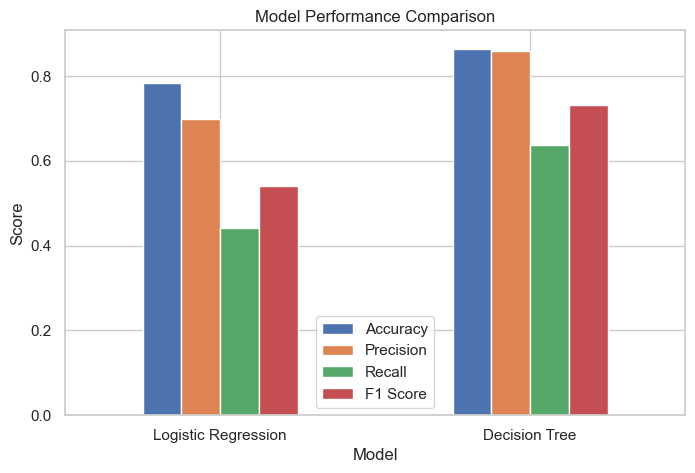

In [188]:
comparison.set_index("Model").plot(
    kind="bar",
    figsize=(8,5)
)
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

### **Model Comparison Analysis**

#### Accuracy

Accuracy measures the percentage of correctly classified customers. The model with the higher accuracy performs better overall.

#### Precision

Precision measures how many predicted churn customers actually churned.

#### Recall

Recall measures the model's ability to correctly identify actual churn customers.

#### F1 Score

F1 Score provides the balance between Precision and Recall.


### **Findings**

* Compare Accuracy of both models.
* Compare Precision.
* Compare Recall.
* Compare F1 Score.
* Identify the better-performing model.

### **Final Conclusion**

The objective of this project was to develop a machine learning model capable of predicting customer churn using historical customer data.
Before model training, data leakage was prevented by removing columns that could reveal the target variable or uniquely identify customers. The dataset was then divided into training and testing sets, and missing or infinite values were handled to ensure high-quality input data.
Two classification algorithms were evaluated: Logistic Regression and Decision Tree Classifier. Their performance was compared using Accuracy, Precision, Recall, F1 Score, Classification Report, and Confusion Matrix.
The model with the higher Accuracy, Recall, and F1 Score is considered the preferred model for predicting customer churn.
These predictions can help businesses identify customers who are likely to leave, improve customer retention strategies, reduce churn, increase customer satisfaction, and support data-driven business decisions.